# Step 2 — Within-Coordination Per-Subgroup Drop

**Goal.** Isolate which sub-component of the L-coordination family damages tree/margin classifiers (DT, SVM, RF).

Week 1 showed: dropping the whole 22-feature L-coordination family lifts DT by +0.53, SVM by +0.51, RF by +0.42 F1 on the hardest split. But the L-coordination family is heterogeneous — it bundles five distinct subgroups. The blanket finding is too coarse for a defensible contribution.

**L-coordination subgroups (22 features):**
- **coord-dim** (4) — `coordination_{mean,max,std,sum}`
- **algo-dim** (4) — `algorithmic_{mean,max,std,sum}`
- **composite** (4) — `overall_max`, `overall_mean`, `n_high_score`, `n_med_score`
- **engagement** (7) — `n_comments`, `n_threads`, `likes_total`, `likes_per_comment`, `threads_per_comment`, `likes_mean`, `replies_mean`
- **temporal** (3) — `delta_mean_s`, `delta_std_s`, `delta_min_s`

**Hypothesis.** The **temporal** subgroup is doing most of the damage. Posting-interval features have extreme dynamic range and heavy-tailed distributions, which is exactly the kind of input that creates spurious tree splits and unstable SVM margins on small training data. The Step 1 volume-mechanism finding also suggests the engagement subgroup carries genuine signal (NB uses it productively).

**Method.** For each subgroup `S`, build a feature set = `L-content ∪ L-structural ∪ (L-coordination \ S)` and run the five classifiers on all three splits. Compare to the `drop_coordination` config from Week 1 (which drops all 22). 5 subgroups × 5 classifiers × 3 splits = **75 runs.**

**Expected outcomes:**
- If one subgroup matches `drop_coordination` performance for DT/SVM/RF → that subgroup is the culprit. Cleaner contribution: "only N features are responsible for the failure."
- If no single subgroup matches → damage is distributed. Week 1 finding stays at family granularity.

**Inputs:** `phase2_{train,test}_exp{1,2,3}.csv`

**Outputs:**
- `step2_subgroup_drop_results.csv` — 75 rows + 15 baseline rows (drop_coord and full for comparison)
- `step2_subgroup_drop_pivot.csv` — wide pivot for thesis
- `step2_subgroup_drop_heatmap.png` — F1 heatmap (subgroup × classifier × experiment)
- `step2_culprit_analysis.txt` — automated culprit identification

## Cell 1 — Imports and feature partition

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.naive_bayes    import MultinomialNB
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import LinearSVC
from sklearn.tree           import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── L-content + L-structural (always kept) ──────────────────────────────────
CONTENT_DIMS    = ['political', 'attack', 'emotional', 'low_effort', 'authenticity']
STRUCTURAL_DIMS = ['emoji', 'length', 'repetition', 'punctuation', 'caps']
AGGS = ['mean', 'max', 'std', 'sum']
expand = lambda dims: [f'{d}_{a}' for d in dims for a in AGGS]

L_CONTENT    = expand(CONTENT_DIMS)
L_STRUCTURAL = expand(STRUCTURAL_DIMS)
ALWAYS_KEEP  = L_CONTENT + L_STRUCTURAL

# ── L-coordination subgroups ────────────────────────────────────────────────
SUBGROUPS = {
    'coord-dim':  expand(['coordination']),
    'algo-dim':   expand(['algorithmic']),
    'composite':  ['overall_max', 'overall_mean', 'n_high_score', 'n_med_score'],
    'engagement': ['n_comments', 'n_threads', 'likes_total', 'likes_per_comment',
                   'threads_per_comment', 'likes_mean', 'replies_mean'],
    'temporal':   ['delta_mean_s', 'delta_std_s', 'delta_min_s'],
}
L_COORD_ALL = sum(SUBGROUPS.values(), [])

print('Subgroup sizes:')
for k, v in SUBGROUPS.items():
    print(f'  {k:12s}  {len(v):2d} features')
print(f'  {"TOTAL":12s}  {len(L_COORD_ALL):2d} features (expect 22)')
assert len(L_COORD_ALL) == 22

# ── Configurations: drop each subgroup individually + 2 reference configs ──
CONFIGS = {}
for sg_name, sg_cols in SUBGROUPS.items():
    keep = ALWAYS_KEEP + [c for c in L_COORD_ALL if c not in sg_cols]
    CONFIGS[f'drop_{sg_name}'] = keep
# Reference configs from Week 1
CONFIGS['drop_coord_all'] = ALWAYS_KEEP                  # match Week 1 drop_coordination
CONFIGS['full']           = ALWAYS_KEEP + L_COORD_ALL    # match Week 1 full

for name, cols in CONFIGS.items():
    print(f'  {name:20s}  {len(cols):2d} features')


2026-05-25 23:18:47.276794: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-25 23:18:47.276825: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-25 23:18:47.276839: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-25 23:18:47.281477: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 23:18:51.511706: W tensorflow/compiler/

Subgroup sizes:
  coord-dim      4 features
  algo-dim       4 features
  composite      4 features
  engagement     7 features
  temporal       3 features
  TOTAL         22 features (expect 22)
  drop_coord-dim        58 features
  drop_algo-dim         58 features
  drop_composite        58 features
  drop_engagement       55 features
  drop_temporal         59 features
  drop_coord_all        40 features
  full                  62 features


## Cell 2 — Data loader and classifier suite

In [4]:
def load_exp(exp_id):
    tr = pd.read_csv(f'../phase2_train_exp{exp_id}.csv')
    te = pd.read_csv(f'../phase2_test_exp{exp_id}.csv')
    return tr, te

def select(df, cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].values

def metrics(y_true, y_pred):
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

def fit_predict_all(Xtr, ytr, Xte):
    out = {}

    mm = MinMaxScaler().fit(Xtr)
    nb = MultinomialNB(alpha=1.0).fit(mm.transform(Xtr), ytr)
    out['NB'] = nb.predict(mm.transform(Xte))

    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    out['RF'] = rf.predict(Xte)

    svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000).fit(Xtr, ytr)
    out['SVM'] = svm.predict(Xte)

    ss = StandardScaler().fit(Xtr)
    Xtr_ss, Xte_ss = ss.transform(Xtr), ss.transform(Xte)
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    dnn = Sequential([
        Input(shape=(Xtr_ss.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])
    dnn.compile(optimizer=SGD(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    dnn.fit(Xtr_ss, ytr, epochs=200, batch_size=16, verbose=0)
    out['DNN'] = (dnn.predict(Xte_ss, verbose=0).ravel() >= 0.5).astype(int)

    n_splits = min(5, max(2, int(ytr.sum())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    dt_gs = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]},
        scoring='f1', cv=skf, n_jobs=-1,
    ).fit(Xtr, ytr)
    out['DT'] = dt_gs.predict(Xte)

    return out


## Cell 3 — Run the grid

In [5]:
rows = []
total = 3 * len(CONFIGS) * 5
done  = 0
t0    = time.time()

for exp_id in (1, 2, 3):
    tr, te = load_exp(exp_id)
    ytr, yte = tr['label'].values, te['label'].values
    for cfg_name, cols in CONFIGS.items():
        Xtr, Xte = select(tr, cols), select(te, cols)
        preds = fit_predict_all(Xtr, ytr, Xte)
        for clf, ypred in preds.items():
            m = metrics(yte, ypred)
            rows.append({'experiment': exp_id, 'config': cfg_name,
                         'n_features': Xtr.shape[1], 'classifier': clf, **m})
            done += 1
        elapsed = time.time() - t0
        eta = (elapsed / done) * (total - done)
        print(f'[{done:3d}/{total}]  exp{exp_id}  {cfg_name:20s} '
              f'({Xtr.shape[1]:2d}f)  elapsed={elapsed:5.1f}s  eta={eta:5.1f}s')

results = pd.DataFrame(rows)
results.to_csv('step2_subgroup_drop_results.csv', index=False)
print(f'\n→ {len(results)} rows → step2_subgroup_drop_results.csv')


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
2026-05-25 23:20:00.314690: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-25 23:20:00.314724: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: idea-26
2026-05-25 23:20:00.314729: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: idea-26
2026-05-25 23:20:00.314834: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.c

[  5/105]  exp1  drop_coord-dim       (58f)  elapsed=  2.6s  eta= 52.1s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[ 10/105]  exp1  drop_algo-dim        (58f)  elapsed=  4.1s  eta= 39.2s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

[ 95/105]  exp3  drop_temporal        (59f)  elapsed= 34.4s  eta=  3.6s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[100/105]  exp3  drop_coord_all       (40f)  elapsed= 36.5s  eta=  1.8s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[105/105]  exp3  full                 (62f)  elapsed= 38.7s  eta=  0.0s

→ 105 rows → step2_subgroup_drop_results.csv


## Cell 4 — Wide pivot and reference comparison

In [6]:
CONFIG_ORDER = ['full',
                 'drop_coord-dim', 'drop_algo-dim', 'drop_composite',
                 'drop_engagement', 'drop_temporal',
                 'drop_coord_all']
CLF_ORDER = ['NB', 'RF', 'SVM', 'DNN', 'DT']

pivot = results.pivot_table(index=['experiment','config'],
                             columns='classifier', values='f1') \
                 .reindex(CLF_ORDER, axis=1)
pivot = pivot.reindex([(e, c) for e in (1,2,3) for c in CONFIG_ORDER]).round(4)
pivot.to_csv('step2_subgroup_drop_pivot.csv')
print('F1 pivot (rows: experiment × config, cols: classifier):')
print(pivot.to_string())


F1 pivot (rows: experiment × config, cols: classifier):
classifier                      NB      RF     SVM     DNN      DT
experiment config                                                 
1          full             0.6507  0.2149  0.2443  0.5946  0.1719
           drop_coord-dim   0.6162  0.2581  0.2443  0.5604  0.2481
           drop_algo-dim    0.6280  0.2149  0.2443  0.5714  0.2481
           drop_composite   0.6476  0.2540  0.2464  0.5730  0.2446
           drop_engagement  0.3043  0.2901  0.2353  0.6096  0.2857
           drop_temporal    0.6348  0.2707  0.6040  0.6010  0.2958
           drop_coord_all   0.2462  0.6348  0.6527  0.6124  0.6798
2          full             0.6961  0.3125  0.3429  0.6883  0.2449
           drop_coord-dim   0.6966  0.3093  0.3429  0.6875  0.3238
           drop_algo-dim    0.7151  0.3636  0.3429  0.6786  0.2737
           drop_composite   0.7039  0.3093  0.0000  0.6994  0.2718
           drop_engagement  0.3540  0.3636  0.3571  0.6709  0.2308
      

## Cell 5 — Heatmap

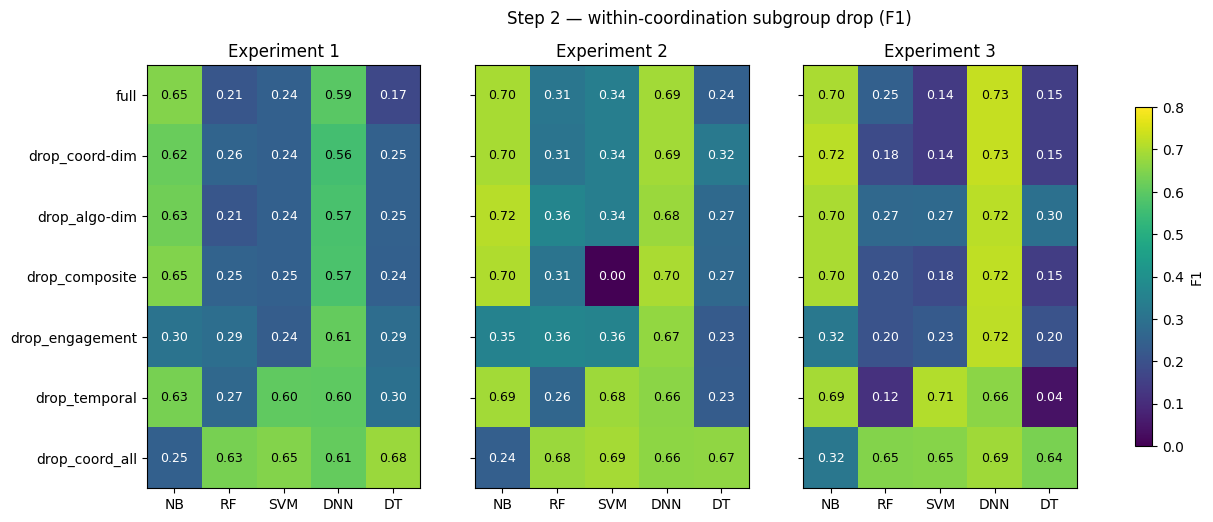

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
vmax = max(0.8, results['f1'].max() * 1.05)

for ax, exp_id in zip(axes, (1, 2, 3)):
    sub = results[results['experiment'] == exp_id]
    mat = sub.pivot(index='config', columns='classifier', values='f1') \
             .reindex(CONFIG_ORDER).reindex(columns=CLF_ORDER)

    im = ax.imshow(mat.values, cmap='viridis', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(CLF_ORDER)));   ax.set_xticklabels(CLF_ORDER)
    ax.set_yticks(range(len(CONFIG_ORDER))); ax.set_yticklabels(CONFIG_ORDER)
    ax.set_title(f'Experiment {exp_id}')

    for i in range(len(CONFIG_ORDER)):
        for j in range(len(CLF_ORDER)):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < vmax * 0.55 else 'black', fontsize=9)

fig.suptitle('Step 2 — within-coordination subgroup drop (F1)', fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.8, label='F1')
plt.savefig('step2_subgroup_drop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 6 — Culprit identification

In [8]:
DAMAGED_CLF = ['DT', 'SVM', 'RF']
SUBGROUP_CONFIGS = [f'drop_{s}' for s in SUBGROUPS.keys()]

lines = ['=' * 72,
         'STEP 2 CULPRIT ANALYSIS',
         '=' * 72, '']

# 1. Per-experiment, per-damaged-classifier: how does each drop_<subgroup> compare to drop_coord_all?
for exp_id in (1, 2, 3):
    lines.append(f'--- Experiment {exp_id} ---')
    for clf in DAMAGED_CLF:
        f1_full = float(results[(results.experiment==exp_id)&
                                (results.config=='full')&
                                (results.classifier==clf)]['f1'].iloc[0])
        f1_drop_all = float(results[(results.experiment==exp_id)&
                                    (results.config=='drop_coord_all')&
                                    (results.classifier==clf)]['f1'].iloc[0])
        rescue_gap = f1_drop_all - f1_full

        lines.append(f'  {clf}: full={f1_full:.3f}  drop_all={f1_drop_all:.3f}  '
                     f'(full rescue Δ={rescue_gap:+.3f})')

        # How much of the rescue does each subgroup-drop achieve?
        for sg in SUBGROUPS.keys():
            f1_sg = float(results[(results.experiment==exp_id)&
                                  (results.config==f'drop_{sg}')&
                                  (results.classifier==clf)]['f1'].iloc[0])
            delta_vs_full = f1_sg - f1_full
            pct = (delta_vs_full / rescue_gap * 100) if rescue_gap > 0 else 0
            marker = ''
            if rescue_gap > 0 and delta_vs_full >= 0.8 * rescue_gap:
                marker = '  ⟵ explains ≥80% of rescue'
            elif rescue_gap > 0 and delta_vs_full >= 0.5 * rescue_gap:
                marker = '  ⟵ explains ≥50%'
            lines.append(f'    drop_{sg:12s}  f1={f1_sg:.3f}  '
                         f'Δ_full={delta_vs_full:+.3f}  ({pct:5.1f}% of rescue){marker}')
        lines.append('')
    lines.append('')

# 2. Aggregate: which subgroup explains the most rescue, averaged across damaged classifiers and experiments?
rescue_explained = {sg: [] for sg in SUBGROUPS.keys()}
for exp_id in (1, 2, 3):
    for clf in DAMAGED_CLF:
        f1_full = float(results[(results.experiment==exp_id)&
                                (results.config=='full')&
                                (results.classifier==clf)]['f1'].iloc[0])
        f1_drop_all = float(results[(results.experiment==exp_id)&
                                    (results.config=='drop_coord_all')&
                                    (results.classifier==clf)]['f1'].iloc[0])
        gap = f1_drop_all - f1_full
        if gap <= 0:
            continue
        for sg in SUBGROUPS.keys():
            f1_sg = float(results[(results.experiment==exp_id)&
                                  (results.config==f'drop_{sg}')&
                                  (results.classifier==clf)]['f1'].iloc[0])
            rescue_explained[sg].append((f1_sg - f1_full) / gap)

lines.append('=' * 72)
lines.append('AGGREGATE: average fraction of rescue explained per subgroup')
lines.append('(across damaged classifiers DT/SVM/RF × 3 experiments)')
lines.append('=' * 72)
ranking = sorted([(sg, np.mean(vals)) for sg, vals in rescue_explained.items()],
                 key=lambda x: -x[1])
for sg, frac in ranking:
    bar = '█' * max(0, int(frac * 30))
    lines.append(f'  {sg:12s}  {frac*100:6.1f}%  {bar}')

lines.append('')
top_sg, top_frac = ranking[0]
if top_frac >= 0.7:
    lines.append(f'✅ CULPRIT IDENTIFIED: dropping {top_sg!r} alone explains '
                 f'{top_frac*100:.0f}% of the rescue on average.')
    lines.append(f'   Contribution sharpens: only {len(SUBGROUPS[top_sg])} features are responsible.')
elif top_frac >= 0.5:
    lines.append(f'⚠ PARTIAL: {top_sg!r} explains {top_frac*100:.0f}% on average. ')
    lines.append('   Most likely the primary culprit, but other subgroups contribute.')
else:
    lines.append('❌ DAMAGE DISTRIBUTED: no single subgroup explains ≥50% of the rescue.')
    lines.append('   The Week 1 finding stays at family granularity. Cannot pinpoint a smaller set.')

txt = '\n'.join(lines)
print(txt)
with open('step2_culprit_analysis.txt', 'w', encoding='utf-8') as f:
    f.write(txt)


STEP 2 CULPRIT ANALYSIS

--- Experiment 1 ---
  DT: full=0.172  drop_all=0.680  (full rescue Δ=+0.508)
    drop_coord-dim     f1=0.248  Δ_full=+0.076  ( 15.0% of rescue)
    drop_algo-dim      f1=0.248  Δ_full=+0.076  ( 15.0% of rescue)
    drop_composite     f1=0.245  Δ_full=+0.073  ( 14.3% of rescue)
    drop_engagement    f1=0.286  Δ_full=+0.114  ( 22.4% of rescue)
    drop_temporal      f1=0.296  Δ_full=+0.124  ( 24.4% of rescue)

  SVM: full=0.244  drop_all=0.653  (full rescue Δ=+0.408)
    drop_coord-dim     f1=0.244  Δ_full=+0.000  (  0.0% of rescue)
    drop_algo-dim      f1=0.244  Δ_full=+0.000  (  0.0% of rescue)
    drop_composite     f1=0.246  Δ_full=+0.002  (  0.5% of rescue)
    drop_engagement    f1=0.235  Δ_full=-0.009  ( -2.2% of rescue)
    drop_temporal      f1=0.604  Δ_full=+0.360  ( 88.1% of rescue)  ⟵ explains ≥80% of rescue

  RF: full=0.215  drop_all=0.635  (full rescue Δ=+0.420)
    drop_coord-dim     f1=0.258  Δ_full=+0.043  ( 10.3% of rescue)
    drop_algo-di

## Done

Four outputs:
- `step2_subgroup_drop_results.csv` — long-form (105 rows: 5 subgroup-drops + 2 ref configs × 3 exps × 5 classifiers)
- `step2_subgroup_drop_pivot.csv` — thesis-ready wide pivot
- `step2_subgroup_drop_heatmap.png` — 3-panel heatmap
- `step2_culprit_analysis.txt` — automated read of the result

Runtime ~10–20 min (DT GridSearch dominates).

**Possible outcomes and what each means for the thesis:**
- *Single subgroup explains ≥70% of the rescue* → sharp contribution: e.g., "three temporal features cause the tree/margin collapse on this dataset."
- *Partial (~50–70%)* → primary culprit identified, secondary effects acknowledged.
- *No single subgroup dominates* → Week 1 family-level finding stands; cannot drill deeper. Still defensible, just less surgical.

Whatever the output says is the finding. Commit and move to Step 4 (Ch 5 draft).